In [ ]:
import numpy as np
import pandas as pd

from matplotlib import pyplot as plt
import seaborn as sns

import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.filterwarnings("ignore")
warnings.simplefilter("ignore", ConvergenceWarning)

In [ ]:
data = pd.read_csv("Superstore_Data.csv")

In [ ]:
data.head()

,Order Date,Sales,Profit
0,17-10-2013,5175.171,919.971
1,07-11-2011,1822.080,564.840
2,14-04-2012,5244.840,996.480
3,06-06-2013,3701.520,1036.080
4,25-02-2012,1878.720,582.360


In [ ]:
data.dtypes

Order Date     object
Sales         float64
Profit        float64
dtype: object

In [ ]:
data["Order Date"] = pd.to_datetime(data["Order Date"])

In [ ]:
data.dtypes

Order Date    datetime64[ns]
Sales                float64
Profit               float64
dtype: object

In [ ]:
data.head()

,Order Date,Sales,Profit
0,2013-10-17,5175.171,919.971
1,2011-11-07,1822.080,564.840
2,2012-04-14,5244.840,996.480
3,2013-06-06,3701.520,1036.080
4,2012-02-25,1878.720,582.360


In [ ]:
data.sort_values(by="Order Date", inplace=True)

In [ ]:
data.head()

,Order Date,Sales,Profit
5073,2011-01-01,55.242,15.342
3056,2011-01-01,120.366,36.036
4083,2011-01-01,113.670,37.770
424,2011-01-03,912.456,-319.464
5517,2011-01-03,6.006,0.546


In [ ]:
data.reset_index(drop=True, inplace=True)

In [ ]:
data.head()

,Order Date,Sales,Profit
0,2011-01-01,55.242,15.342
1,2011-01-01,120.366,36.036
2,2011-01-01,113.670,37.770
3,2011-01-03,912.456,-319.464
4,2011-01-03,6.006,0.546


In [ ]:
data.set_index("Order Date", inplace=True)

In [ ]:
data.head()

,Sales,Profit
Order Date,,
2011-01-01,55.242,15.342
2011-01-01,120.366,36.036
2011-01-01,113.670,37.770
2011-01-03,912.456,-319.464
2011-01-03,6.006,0.546


In [ ]:
data.loc["2011-01-03"]

,Sales,Profit
Order Date,,
2011-01-03,912.4560,-319.4640
2011-01-03,6.0060,0.5460
2011-01-03,159.4440,-95.6760
2011-01-03,135.1182,-45.9018
2011-01-03,211.1805,-70.3995
2011-01-03,69.3000,3.4200
2011-01-03,337.6395,-122.8005
2011-01-03,68.8680,-26.4120


In [ ]:
data.loc["2011-01-03":"2012-11-10"].sum()

Sales     620926.8645
Profit     77700.3945
dtype: float64

In [ ]:
data.shape

(5699, 2)

In [ ]:
data = data.groupby(pd.Grouper(freq="M")).sum()

In [ ]:
data.shape

(48, 2)

In [ ]:
data.head()

,Sales,Profit
Order Date,,
2011-01-31,15711.7125,991.2825
2011-02-28,12910.8588,1338.8688
2011-03-31,19472.5632,3747.1632
2011-04-30,15440.3046,3846.4746
2011-05-31,24348.9723,3639.9423


In [ ]:
data.drop(columns="Profit", inplace=True)

In [ ]:
data.head()

,Sales
Order Date,
2011-01-31,15711.7125
2011-02-28,12910.8588
2011-03-31,19472.5632
2011-04-30,15440.3046
2011-05-31,24348.9723


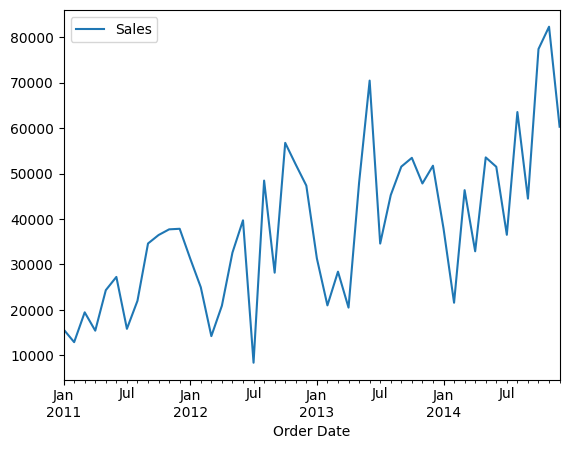

In [ ]:
data.plot()
plt.show()

In [ ]:
from statsmodels.tsa.stattools import adfuller

In [ ]:
results = adfuller(data["Sales"])

In [ ]:
print(f"ADF Statistic: {results[0]}")

ADF Statistic: -2.220856994146368


In [ ]:
print(f"ADF Statistic: {results[1]}")

ADF Statistic: 0.19876283969416958


In [ ]:
df_train = data[0:42]
df_test = data[42:]

Text(0.5, 1.0, 'Sales Data')

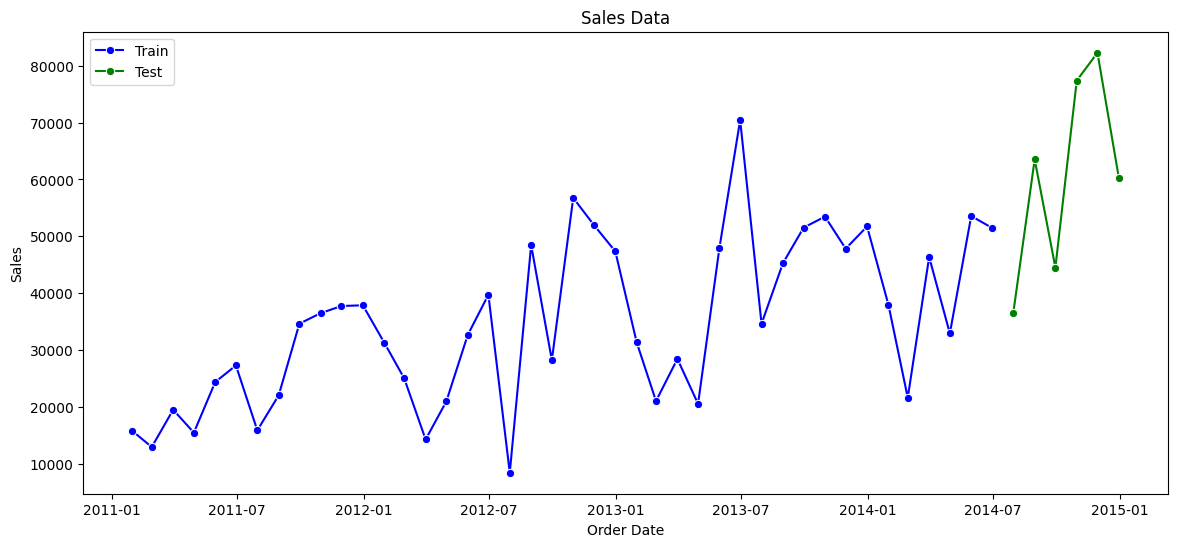

In [ ]:
# Plot the time series data with the train-test split
plt.figure(figsize=(14, 6))
sns.lineplot(
    data=df_train, x="Order Date", y="Sales", marker="o", color="blue", label="Train"
)
sns.lineplot(
    data=df_test, x="Order Date", y="Sales", marker="o", color="green", label="Test"
)
plt.title("Sales Data")

In [ ]:
from scipy.stats import boxcox

In [ ]:
df_boxcox = pd.Series(boxcox(df_train["Sales"], lmbda=0), index=df_train.index)

Text(0.5, 0.98, 'Sales Data')

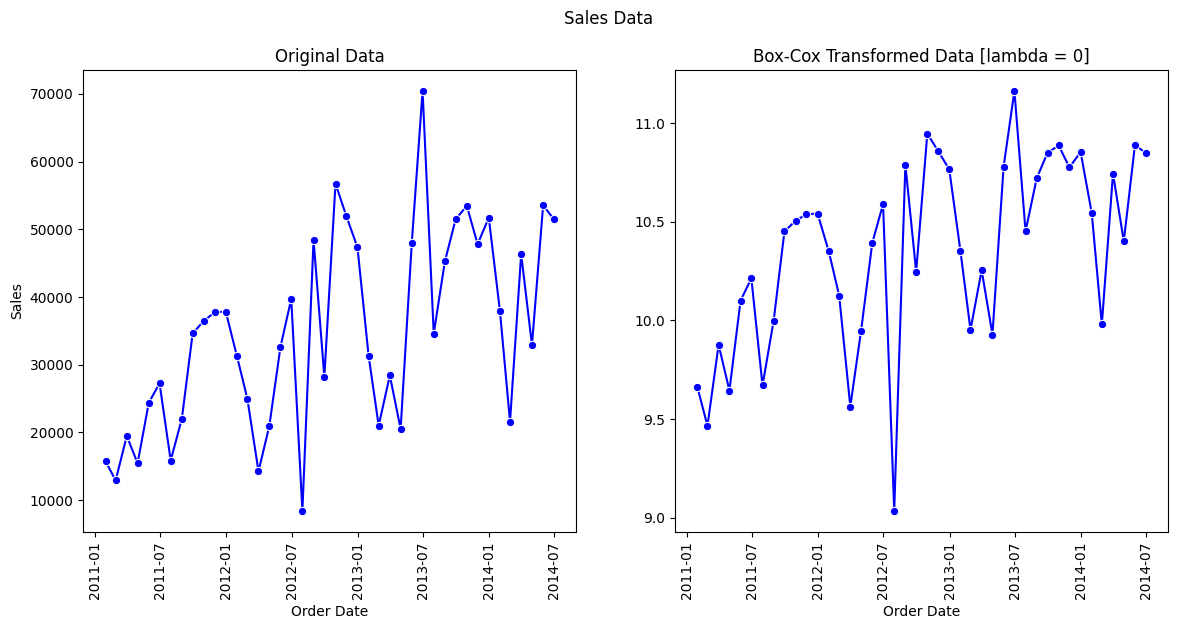

In [ ]:
# Plot the original time series data and its Box-Cox transformed version
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.lineplot(data=df_train, x="Order Date", y="Sales", marker="o", color="blue")
plt.xticks(rotation=90)
plt.title("Original Data")

plt.subplot(1, 2, 2)
sns.lineplot(x=df_boxcox.index, y=df_boxcox.values, marker="o", color="blue")
plt.xticks(rotation=90)
plt.title("Box-Cox Transformed Data [lambda = 0]")

plt.suptitle("Sales Data")

In [ ]:
df_differenced = df_train["Sales"].diff()

Text(0.5, 0.98, 'Sales Data')

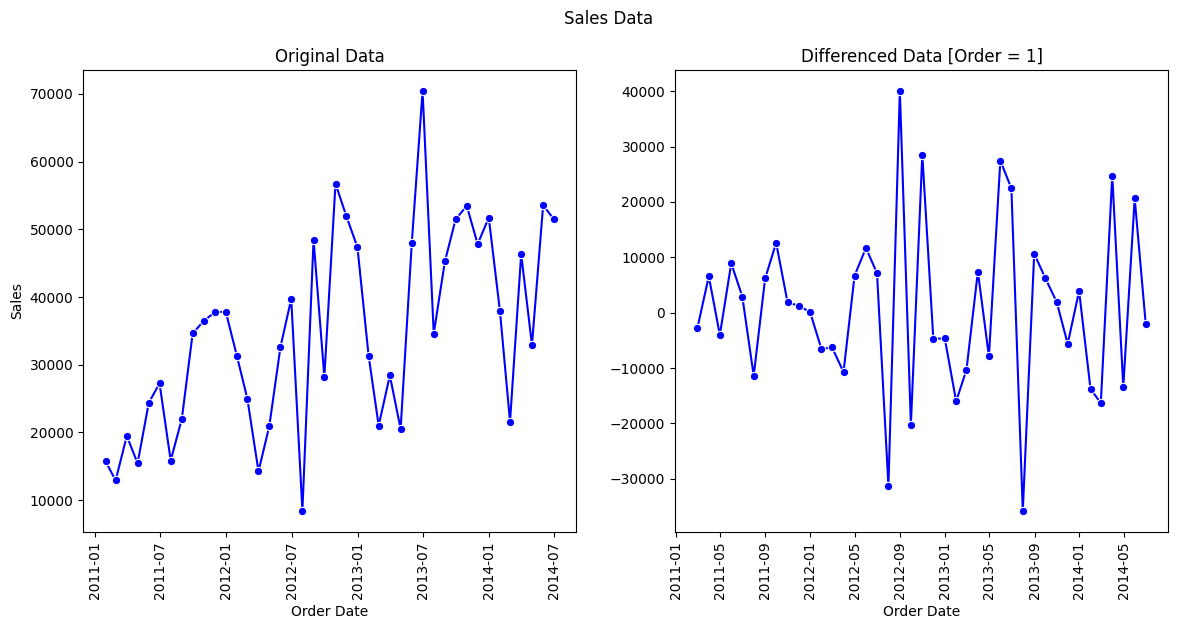

In [ ]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.lineplot(data=df_train, x="Order Date", y="Sales", marker="o", color="blue")
plt.xticks(rotation=90)
plt.title("Original Data")

plt.subplot(1, 2, 2)
sns.lineplot(x=df_differenced.index, y=df_differenced.values, marker="o", color="blue")
plt.xticks(rotation=90)
plt.title("Differenced Data [Order = 1]")
plt.suptitle("Sales Data")

In [ ]:
df_boxcox = pd.Series(boxcox(df_train["Sales"], lmbda=0), index=df_train.index)
df_boxcox_diff = df_boxcox.diff()

Text(0.5, 0.98, 'Sales Data')

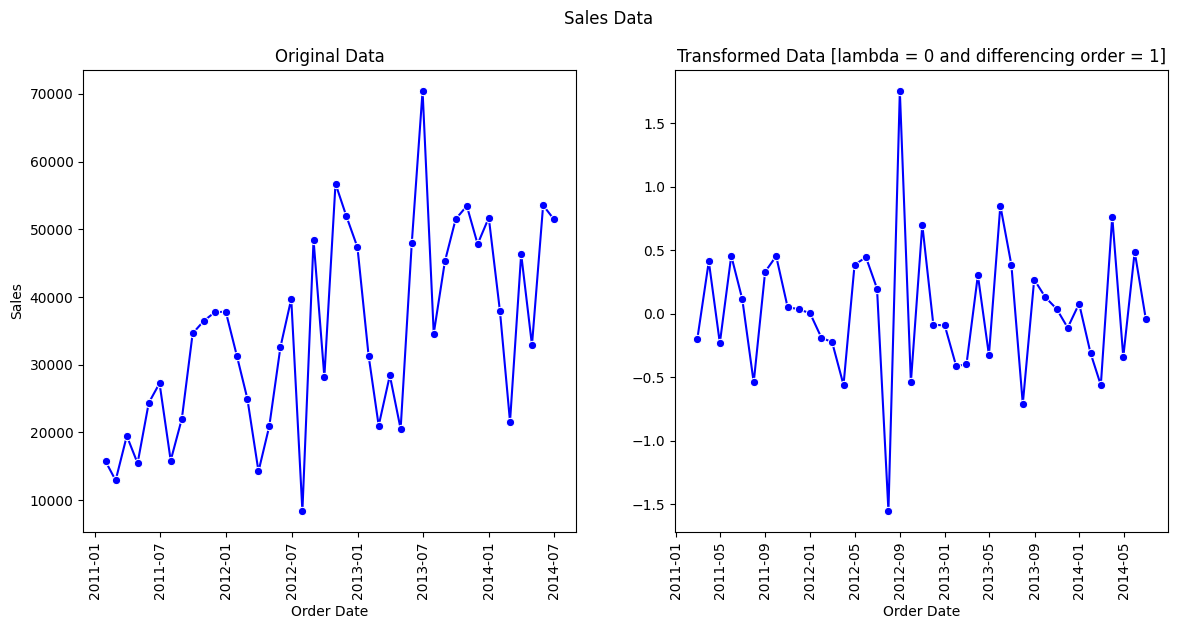

In [ ]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.lineplot(data=df_train, x="Order Date", y="Sales", marker="o", color="blue")
plt.xticks(rotation=90)
plt.title("Original Data")

plt.subplot(1, 2, 2)
sns.lineplot(x=df_boxcox_diff.index, y=df_boxcox_diff.values, marker="o", color="blue")
plt.xticks(rotation=90)
plt.title("Transformed Data [lambda = 0 and differencing order = 1]")
plt.suptitle("Sales Data")

In [ ]:
result_after_transformation = adfuller(df_boxcox_diff[1:])

In [ ]:
result_after_transformation[1]

7.45221173775227e-06

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf

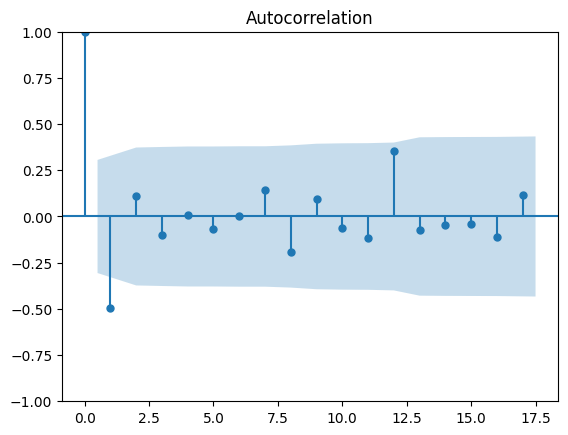

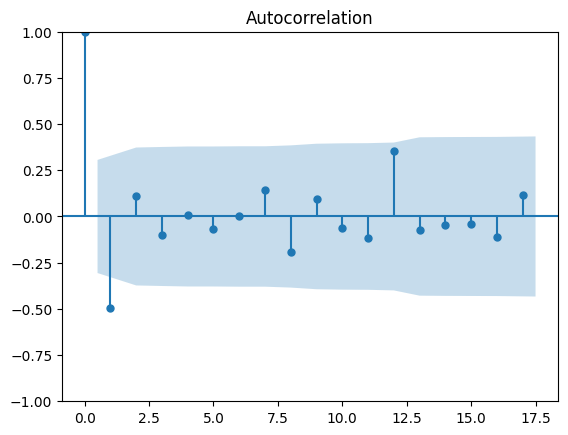

In [ ]:
plot_acf(df_boxcox_diff[1:])

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

In [ ]:
ar_model = ARIMA(df_boxcox_diff, order=(1, 0, 0))
ar_model = ar_model.fit()

In [ ]:
train_len = 42
ar_model_preds = ar_model.predict(start=train_len, end=len(data) - 1)

In [ ]:
ar_model_preds

2014-07-31    0.065469
2014-08-31    0.014786
2014-09-30    0.039315
2014-10-31    0.027443
2014-11-30    0.033189
2014-12-31    0.030408
Freq: ME, Name: predicted_mean, dtype: float64

In [ ]:
df_boxcox_diff_preds = pd.concat([df_boxcox_diff, ar_model_preds])

In [ ]:
df_boxcox_preds = df_boxcox_diff_preds.cumsum()  # cummulative series
df_boxcox_preds = df_boxcox_preds.add(df_boxcox[0])  # initial value adjustment

In [ ]:
df_preds = np.exp(df_boxcox_preds)

Text(0.5, 1.0, 'Sales Data')

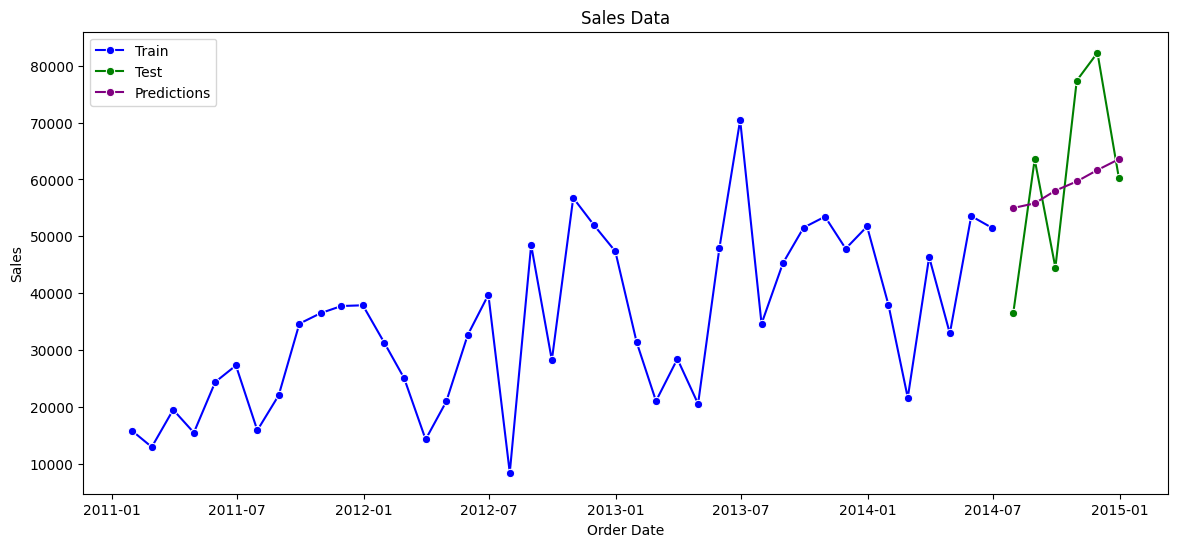

In [ ]:
plt.figure(figsize=(14, 6))
sns.lineplot(data=df_train, x="Order Date", y="Sales", marker="o", color="blue", label="Train")
sns.lineplot(data=df_test, x="Order Date", y="Sales", marker="o", color="green", label="Test")
sns.lineplot(
    x=df_preds.index[train_len:],
    y=df_preds.values[train_len:],
    marker="o",
    color="purple",
    label="Predictions",
)
plt.title("Sales Data")

In [ ]:
from sklearn.metrics import mean_squared_error

In [ ]:
rmse = np.sqrt(mean_squared_error(y_true=df_test["Sales"], y_pred=df_preds.values[train_len:]))

rmse = np.round(rmse, 2)

performance_df = pd.DataFrame(index=[0], data={"Model": "AR", "RMSE": rmse})

performance_df.set_index("Model", inplace=True)

performance_df

,RMSE
Model,
AR,14915.16


In [ ]:
arima_model = ARIMA(df_boxcox, order=(1, 0, 1))
arima_model = arima_model.fit()

In [ ]:
train_len = 42
arima_model_preds = arima_model.predict(start=train_len, end=len(data) - 1)

In [ ]:
df_boxcox_preds = pd.concat([df_boxcox, arima_model_preds])

In [ ]:
df_preds = np.exp(df_boxcox_preds)

Text(0.5, 1.0, 'Sales Data')

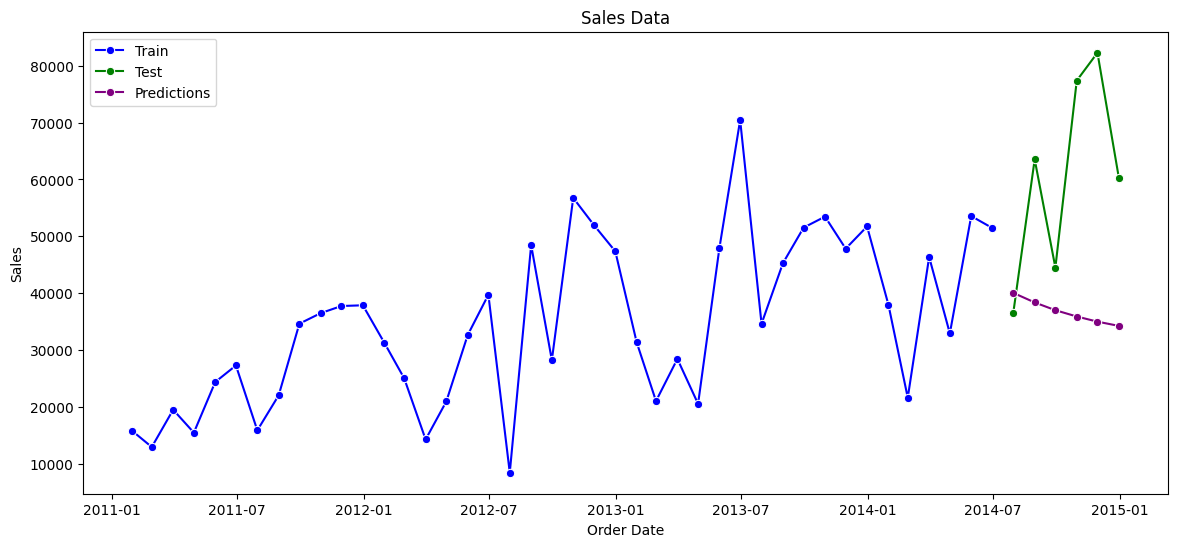

In [ ]:
plt.figure(figsize=(14, 6))
sns.lineplot(data=df_train, x="Order Date", y="Sales", marker="o", color="blue", label="Train")
sns.lineplot(data=df_test, x="Order Date", y="Sales", marker="o", color="green", label="Test")
sns.lineplot(
    x=df_preds.index[train_len:],
    y=df_preds.values[train_len:],
    marker="o",
    color="purple",
    label="Predictions",
)
plt.title("Sales Data")

In [ ]:
rmse = np.sqrt(mean_squared_error(y_true=df_test["Sales"], y_pred=df_preds.values[train_len:]))

rmse = np.round(rmse, 2)

performance_df_temp = pd.DataFrame(index=[0], data={"Model": "ARIMA", "RMSE": rmse})

performance_df_temp.set_index("Model", inplace=True)

performance_df = pd.concat([performance_df, performance_df_temp])

performance_df

,RMSE
Model,
AR,14915.16
ARIMA,29842.05


In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [ ]:
sarima_model = SARIMAX(df_boxcox, order=(1, 0, 1), seasonal_order=(1, 0, 1, 12))
sarima_model = sarima_model.fit()

In [ ]:
train_len = 42
sarima_model_preds = sarima_model.predict(start=train_len, end=len(data) - 1)

In [ ]:
df_boxcox_preds = pd.concat([df_boxcox, sarima_model_preds])

In [ ]:
df_preds = np.exp(df_boxcox_preds)

Text(0.5, 1.0, 'Sales Data')

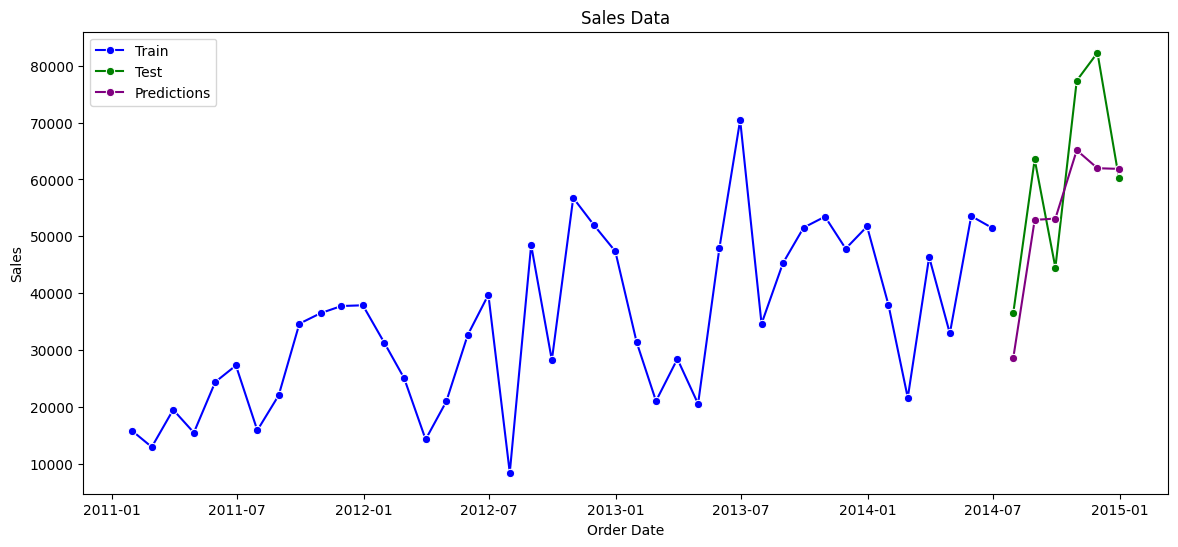

In [ ]:
plt.figure(figsize=(14, 6))
sns.lineplot(data=df_train, x="Order Date", y="Sales", marker="o", color="blue", label="Train")
sns.lineplot(data=df_test, x="Order Date", y="Sales", marker="o", color="green", label="Test")
sns.lineplot(
    x=df_preds.index[train_len:],
    y=df_preds.values[train_len:],
    marker="o",
    color="purple",
    label="Predictions",
)
plt.title("Sales Data")

In [ ]:
rmse = np.sqrt(mean_squared_error(y_true=df_test["Sales"], y_pred=df_preds.values[train_len:]))

rmse = np.round(rmse, 2)

performance_df_temp = pd.DataFrame(index=[0], data={"Model": "SARIMA", "RMSE": rmse})

performance_df_temp.set_index("Model", inplace=True)

performance_df = pd.concat([performance_df, performance_df_temp])

performance_df

,RMSE
Model,
AR,14915.16
ARIMA,29842.05
SARIMA,11661.64
